# Phase 2 — Grounding DINO Zero-Shot on VME

Grounding DINO (Liu et al., ECCV 2024) evaluated zero-shot on the VME car test set. The motivation comes from the RWDS benchmark (Al-Emadi et al., CVPR 2025): open-vocabulary detectors degrade far less across geographic shift than trained detectors, so GDINO might recover cars the Phase 1 baseline misses and serve as a useful pseudo-label source for Phase 3.

Five text prompts are tested; the best is used for the robustness comparison against Phase 1 and to generate pseudo-labels on the VME training set. Results are new — neither anchor paper evaluates GDINO on VME directly.

Outputs go to `QCRI-CV/phase2/`. Phase 1 results are read from `phase1/results/phase1_results.json`.

---
# Section 1 — Environment
Run at the start of every session. Grounding DINO is served entirely by the `transformers` library; the MMDetection stack from Phase 1 is not required here, so this notebook keeps a separate, lighter dependency set to avoid version conflicts.

### 1.1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 — Dependencies

In [ ]:
!pip install -q -U transformers
!pip install -q pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 155.0 MB/s eta 0:00:00


### 1.3 — Imports and device

In [ ]:
import os, io, json, inspect, contextlib
import numpy as np
import torch
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import transformers

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch {torch.__version__} | CUDA {torch.cuda.is_available()} | transformers {transformers.__version__}')
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | CUDA True | transformers 5.12.0
GPU: NVIDIA A100-SXM4-40GB


### 1.4 — Weights & Biases login

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: haytham-bd (haytham-bd-valeo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Section 2 — Configuration
Prompts, confidence thresholds, and paths. Thresholds are set low to maximise recall for the mAP sweep; they are held constant across prompts so the ablation is a fair comparison. The xView local copy cell only needs to run before Section 8.

In [ ]:
import os, json, datetime

BASE = '/content/drive/MyDrive/QCRI-CV'
P1   = f'{BASE}/phase1'                         # Phase 1 outputs (read-only here)
ROOT = f'{BASE}/phase2'                          # Phase 2 outputs

VME_TEST_ANN = f'{P1}/annotations/vme/test.json'
VME_TRAIN_ANN = f'{P1}/annotations/vme/train.json'
VME_IMGS     = f'{BASE}/VME_CDSI_datasets/satellite_images'
XVIEW_TEST_ANN = f'{P1}/annotations/xview/xview_car_test.json'
XVIEW_IMGS   = '/content/xview_images'           # local copy (see note below)

PREDS   = f'{ROOT}/preds'
FIGS    = f'{ROOT}/figures'
PSEUDO  = f'{ROOT}/pseudo_labels'
RESULTS_JSON = f'{ROOT}/results/phase2_results.json'
P1_RESULTS_JSON = f'{P1}/results/phase1_results.json'

for d in [PREDS, FIGS, PSEUDO, f'{ROOT}/results']:
    os.makedirs(d, exist_ok=True)

MODEL_ID = 'IDEA-Research/grounding-dino-base'   # Swin-B + BERT

PROMPTS = [
    'car',
    'vehicle',
    'small car',
    'small car in aerial image',
    'vehicle in satellite image',
]

BOX_THRESHOLD  = 0.05
TEXT_THRESHOLD = 0.05
USE_FP16 = False

def save_result(key, payload):
    db = json.load(open(RESULTS_JSON)) if os.path.exists(RESULTS_JSON) else {}
    payload = dict(payload)
    payload['_saved'] = datetime.datetime.now().isoformat(timespec='seconds')
    db[key] = payload
    with open(RESULTS_JSON, 'w') as f:
        json.dump(db, f, indent=2)
    print(f'saved -> {key}: {payload}')

def load_results():
    return json.load(open(RESULTS_JSON)) if os.path.exists(RESULTS_JSON) else {}

def load_phase1():
    return json.load(open(P1_RESULTS_JSON)) if os.path.exists(P1_RESULTS_JSON) else {}

print('Output root:', ROOT)
print('Prompts:', PROMPTS)
print(f'box_threshold={BOX_THRESHOLD} text_threshold={TEXT_THRESHOLD} fp16={USE_FP16}')

Output root: /content/drive/MyDrive/QCRI-CV/phase2
Prompts: ['car', 'vehicle', 'small car', 'small car in aerial image', 'vehicle in satellite image']
box_threshold=0.05 text_threshold=0.05 fp16=False


The xView in-domain evaluation in Section 8 reads the large raw frames repeatedly during tiling; copying them to local disk once avoids Drive throttling. Run this before Section 8 (it is not needed for the VME sections).

In [ ]:
import shutil, os, time

os.makedirs(XVIEW_IMGS, exist_ok=True)
src = f'{BASE}/xview/train_images'
tifs = sorted([f for f in os.listdir(src) if f.endswith('.tif')])
already = set(os.listdir(XVIEW_IMGS))

for i, f in enumerate(tifs):
    if f in already:
        continue
    shutil.copy2(f'{src}/{f}', f'{XVIEW_IMGS}/{f}')
    if i % 50 == 0:
        print(f'{i}/{len(tifs)}')
        time.sleep(1)

print(f'Done — {len(os.listdir(XVIEW_IMGS))} files in {XVIEW_IMGS}')

0/846
50/846
100/846
150/846
200/846
250/846
300/846
350/846
400/846
450/846
500/846
550/846
600/846
650/846
700/846
750/846
800/846
Done — 846 files in /content/xview_images


# Section 3 — Grounding DINO
Loads the Swin-B model. The post-processing API changed between `transformers` versions — `threshold` in recent releases, `box_threshold` in older ones — so the keyword is detected at runtime.

In [ ]:
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device).eval()

_pp = inspect.signature(processor.post_process_grounded_object_detection).parameters
THRESH_KW = 'threshold' if 'threshold' in _pp else 'box_threshold'
print('post-process threshold keyword ->', THRESH_KW)
print('Grounding DINO ready on', device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

post-process threshold keyword -> threshold
Grounding DINO ready on cuda


---
# Section 4 — Inference and evaluation helpers
Grounding DINO requires lowercased prompts terminated with a period. The COCO evaluation reads `mAP@[0.50:0.95]` and `mAP50` from fixed indices in the summary statistics, so the metric values are correct regardless of the `maxDets` configuration.

In [ ]:
def norm_prompt(p):
    p = p.strip().lower()
    return p if p.endswith('.') else p + '.'

@torch.no_grad()
def run_gdino(image, prompt_text):
    inputs = processor(images=image, text=prompt_text, return_tensors='pt').to(device)
    if USE_FP16 and device == 'cuda':
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(**inputs)
    else:
        outputs = model(**inputs)
    res = processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        target_sizes=[image.size[::-1]],
        **{THRESH_KW: BOX_THRESHOLD, 'text_threshold': TEXT_THRESHOLD})[0]
    return res['boxes'].cpu().numpy(), res['scores'].cpu().numpy()

def coco_eval(coco_gt, predictions, cat_id, silent=True):
    if not predictions:
        return 0.0, 0.0
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        coco_dt = coco_gt.loadRes(predictions)
        ev = COCOeval(coco_gt, coco_dt, 'bbox')
        ev.params.maxDets = [1, 10, 1000]
        ev.params.catIds = [cat_id]
        ev.evaluate(); ev.accumulate(); ev.summarize()
    if not silent:
        print(buf.getvalue())
    # stats[0] = mAP@[.50:.95] @ maxDets=last; stats[1] = mAP@.50. Both valid under any maxDets list.
    return float(ev.stats[0]), float(ev.stats[1])

coco_gt_vme = COCO(VME_TEST_ANN)
VME_CAT = int(coco_gt_vme.getCatIds()[0])
with open(VME_TEST_ANN) as f:
    vme_data = json.load(f)
print(f"VME test: {len(vme_data['images'])} images, {len(vme_data['annotations'])} annotations | car id = {VME_CAT}")

loading annotations into memory...
Done (t=1.39s)
creating index...
index created!
VME test: 988 images, 26458 annotations | car id = 0


# Section 5 — Prompt ablation on VME test
All 988 VME test frames, five prompts, same confidence threshold throughout. Results logged to W&B.

### 5.1 — Run all prompts

In [ ]:
preds_by_prompt = {p: [] for p in PROMPTS}

for info in tqdm(vme_data['images'], desc='VME prompt ablation'):
    image = Image.open(os.path.join(VME_IMGS, info['file_name'])).convert('RGB')
    for p in PROMPTS:
        boxes, scores = run_gdino(image, norm_prompt(p))
        for (x1, y1, x2, y2), s in zip(boxes, scores):
            preds_by_prompt[p].append({'image_id': info['id'], 'category_id': VME_CAT,
                                       'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                                       'score': float(s)})
for p in PROMPTS:
    print(f"  {p!r:32s} -> {len(preds_by_prompt[p]):>7d} detections")

VME prompt ablation:   0%|          | 0/988 [00:00<?, ?it/s]

  'car'                            ->   76601 detections
  'vehicle'                        ->  168172 detections
  'small car'                      ->  125127 detections
  'small car in aerial image'      ->   91956 detections
  'vehicle in satellite image'     ->   90561 detections


### 5.2 — Score and rank

In [ ]:
rows = []
for p in PROMPTS:
    mAP, mAP50 = coco_eval(coco_gt_vme, preds_by_prompt[p], VME_CAT, silent=True)
    rows.append({'prompt': p, 'mAP50': round(mAP50 * 100, 2),
                 'mAP': round(mAP * 100, 2), 'n_dets': len(preds_by_prompt[p])})

table = pd.DataFrame(rows).sort_values('mAP50', ascending=False).reset_index(drop=True)
best_prompt = table.iloc[0]['prompt']
best_map50  = float(table.iloc[0]['mAP50'])
best_map    = float(table.iloc[0]['mAP'])

p1 = load_phase1()
base50 = p1.get('baseline_vme_test_epoch24', {}).get('mAP50', 'n/a')
orac50 = p1.get('oracle_vme_test_epoch24', {}).get('mAP50', 'n/a')

print(table.to_string(index=False))
print(f"\nBest prompt: {best_prompt!r} at {best_map50:.1f} mAP50")
print(f"Reference (Phase 1): baseline xView->VME {base50} | oracle VME->VME {orac50}")
save_result('gdino_prompt_ablation',
            {'table': rows, 'best_prompt': best_prompt,
             'best_mAP50': best_map50, 'best_mAP': best_map})

                    prompt  mAP50    mAP  n_dets
                       car  14.68 -100.0   76601
                   vehicle  13.63 -100.0  168172
                 small car   7.39 -100.0  125127
 small car in aerial image   2.49 -100.0   91956
vehicle in satellite image   1.88 -100.0   90561

Best prompt: 'car' at 14.7 mAP50
Reference (Phase 1): baseline xView->VME 38.23 | oracle VME->VME 55.58
saved -> gdino_prompt_ablation: {'table': [{'prompt': 'car', 'mAP50': 14.68, 'mAP': -100.0, 'n_dets': 76601}, {'prompt': 'vehicle', 'mAP50': 13.63, 'mAP': -100.0, 'n_dets': 168172}, {'prompt': 'small car', 'mAP50': 7.39, 'mAP': -100.0, 'n_dets': 125127}, {'prompt': 'small car in aerial image', 'mAP50': 2.49, 'mAP': -100.0, 'n_dets': 91956}, {'prompt': 'vehicle in satellite image', 'mAP50': 1.88, 'mAP': -100.0, 'n_dets': 90561}], 'best_prompt': 'car', 'best_mAP50': 14.68, 'best_mAP': -100.0, '_saved': '2026-06-13T17:23:23'}


### 5.3 — Full COCO summary for the best prompt

In [ ]:
print(f'Best prompt: {best_prompt!r}\n')
_ = coco_eval(coco_gt_vme, preds_by_prompt[best_prompt], VME_CAT, silent=False)
save_result('gdino_vme_test_best_prompt',
            {'prompt': best_prompt, 'mAP50': round(best_map50, 2), 'mAP': round(best_map, 2),
             'n_preds': len(preds_by_prompt[best_prompt])})

Best prompt: 'car'

Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=41.91s).
Accumulating evaluation results...
DONE (t=0.43s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.147
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.050
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.007
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.051
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.167
 Average Recall     (AR) @[ IoU=0.50:0

### 5.4 — Log the ablation table to Weights & Biases

In [ ]:
try:
    run = wandb.init(project='qcri-vme-uda', name='gdino-zeroshot-vme', reinit=True)
    wandb.log({'prompt_ablation': wandb.Table(dataframe=table),
               'best_prompt': best_prompt, 'best_mAP50': best_map50})
    run.finish()
    print('Logged to W&B')
except Exception as ex:
    print('W&B logging skipped:', ex)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


best_mAP50,▁
best_mAP50,14.68
best_prompt,car


Logged to W&B


# Section 6 — Best-prompt predictions
Saves the best-prompt detections to disk for use in the qualitative figure, the xView evaluation, and Phase 3 pseudo-label generation.

In [ ]:
best_path = f"{PREDS}/vme_gdino_{best_prompt.replace(' ', '_')}.json"
with open(best_path, 'w') as f:
    json.dump(preds_by_prompt[best_prompt], f)
print(f'Saved {len(preds_by_prompt[best_prompt])} predictions -> {best_path}')

Saved 76601 predictions -> /content/drive/MyDrive/QCRI-CV/phase2/preds/vme_gdino_car.json


---
# Section 7 — Qualitative results
Ground truth in green; Grounding DINO detections with score ≥ 0.3 in red. Two median-density and the two densest test frames.

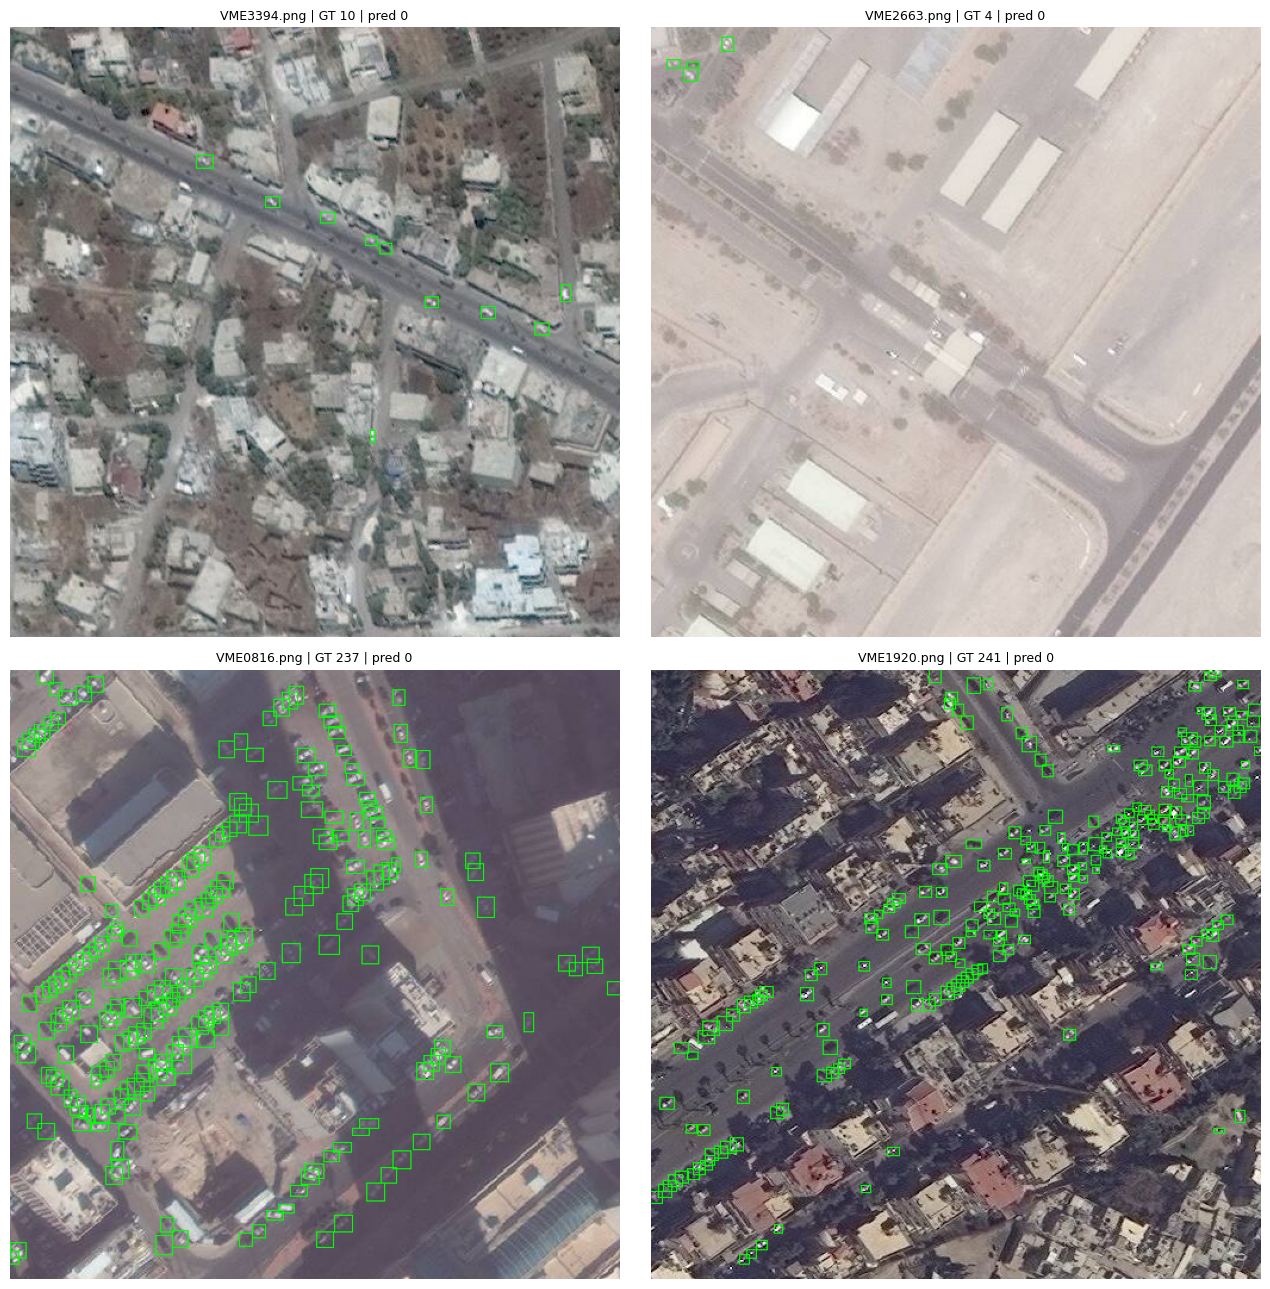

Saved /content/drive/MyDrive/QCRI-CV/phase2/figures/gdino_qualitative.png


In [ ]:
import random, cv2
import matplotlib.pyplot as plt
from collections import defaultdict

by_img = defaultdict(list)
for p in preds_by_prompt[best_prompt]:
    if p['score'] >= 0.3:
        by_img[p['image_id']].append(p)

ids_by_density = sorted(coco_gt_vme.getImgIds(), key=lambda i: len(coco_gt_vme.getAnnIds(imgIds=i)))
random.seed(0)
picks = random.sample(ids_by_density[:len(ids_by_density)//2], 2) + ids_by_density[-2:]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, iid in zip(axes.ravel(), picks):
    info = coco_gt_vme.loadImgs(iid)[0]
    im = cv2.cvtColor(cv2.imread(os.path.join(VME_IMGS, info['file_name'])), cv2.COLOR_BGR2RGB)
    for a in coco_gt_vme.loadAnns(coco_gt_vme.getAnnIds(imgIds=iid)):
        x, y, w, h = map(int, a['bbox']); cv2.rectangle(im, (x, y), (x+w, y+h), (0, 255, 0), 1)
    for p in by_img.get(iid, []):
        x, y, w, h = map(int, p['bbox']); cv2.rectangle(im, (x, y), (x+w, y+h), (255, 0, 0), 1)
    ax.imshow(im); ax.axis('off')
    ax.set_title(f"{info['file_name']} | GT {len(coco_gt_vme.getAnnIds(imgIds=iid))} | pred {len(by_img.get(iid, []))}", fontsize=9)
plt.tight_layout()
out = f'{FIGS}/gdino_qualitative.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print('Saved', out)

---
# Section 8 — xView in-domain evaluation and robustness metrics
To place Grounding DINO on the same Performance Drop / Harmonic Mean axes as the Phase 1 detector, the best prompt is evaluated in-domain on the raw xView test frames. These frames are large, so inference is tiled (512×512, 20% overlap) and the per-tile detections are merged with non-maximum suppression. Requires the local xView copy from Section 2.

### 8.1 — Tiled inference on xView test

In [ ]:
from torchvision.ops import nms

TILE, OVERLAP, NMS_IOU = 512, 0.2, 0.5

def tile_offsets(W, H, tile=TILE, overlap=OVERLAP):
    step = max(int(tile * (1 - overlap)), 1)
    xs = list(range(0, max(W - tile, 0) + 1, step)) or [0]
    ys = list(range(0, max(H - tile, 0) + 1, step)) or [0]
    if W > tile and xs[-1] != W - tile: xs.append(W - tile)
    if H > tile and ys[-1] != H - tile: ys.append(H - tile)
    return [(x, y) for y in ys for x in xs]

@torch.no_grad()
def gdino_tiled(image, prompt_text):
    W, H = image.size
    all_b, all_s = [], []
    for ox, oy in tile_offsets(W, H):
        tile = image.crop((ox, oy, min(ox + TILE, W), min(oy + TILE, H)))
        boxes, scores = run_gdino(tile, prompt_text)
        for (x1, y1, x2, y2), s in zip(boxes, scores):
            all_b.append([x1 + ox, y1 + oy, x2 + ox, y2 + oy]); all_s.append(s)
    if not all_b:
        return np.zeros((0, 4)), np.zeros((0,))
    b = torch.tensor(all_b, dtype=torch.float32)
    s = torch.tensor(all_s, dtype=torch.float32)
    keep = nms(b, s, NMS_IOU)
    return b[keep].numpy(), s[keep].numpy()

coco_gt_xv = COCO(XVIEW_TEST_ANN)
XV_CAT = int(coco_gt_xv.getCatIds()[0])
with open(XVIEW_TEST_ANN) as f:
    xv_data = json.load(f)

xv_preds = []
for info in tqdm(xv_data['images'], desc='xView GDINO (tiled)'):
    image = Image.open(os.path.join(XVIEW_IMGS, info['file_name'])).convert('RGB')
    boxes, scores = gdino_tiled(image, norm_prompt(best_prompt))
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        xv_preds.append({'image_id': info['id'], 'category_id': XV_CAT,
                         'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                         'score': float(s)})
with open(f'{PREDS}/xview_gdino.json', 'w') as f:
    json.dump(xv_preds, f)

xview_map, xview_map50 = coco_eval(coco_gt_xv, xv_preds, XV_CAT, silent=False)
print(f"\nGDINO xView in-domain mAP50: {xview_map50*100:.1f}")
save_result('gdino_xview_test',
            {'prompt': best_prompt, 'mAP50': round(xview_map50*100, 2),
             'mAP': round(xview_map*100, 2), 'n_preds': len(xv_preds)})

loading annotations into memory...
Done (t=0.75s)
creating index...
index created!


xView GDINO (tiled):   0%|          | 0/167 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.40s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=527.72s).
Accumulating evaluation results...
DONE (t=0.57s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.159
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.061
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.007
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.184
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small |

### 8.2 — Performance Drop and Harmonic Mean

In [ ]:
db = load_results()
ood = db['gdino_vme_test_best_prompt']
idd = db['gdino_xview_test']

def performance_drop(id_, o): return 100 * (id_ - o) / id_       # RWDS Eq. 1
def harmonic_mean(id_, o):    return 2 * o * id_ / (o + id_)      # RWDS Eq. 2

pd_50, h_50 = performance_drop(idd['mAP50'], ood['mAP50']), harmonic_mean(idd['mAP50'], ood['mAP50'])
pd_map, h_map = performance_drop(idd['mAP'], ood['mAP']), harmonic_mean(idd['mAP'], ood['mAP'])

print('mAP@[0.50:0.95] (RWDS convention)')
print(f"  ID {idd['mAP']:.1f} | OOD {ood['mAP']:.1f} | PD {pd_map:.1f}% | H {h_map:.1f}")
print('mAP50')
print(f"  ID {idd['mAP50']:.1f} | OOD {ood['mAP50']:.1f} | PD {pd_50:.1f}% | H {h_50:.1f}")

p1 = load_phase1().get('baseline_pd_h', {})
print(f"\nPhase 1 TOOD baseline for comparison: PD(mAP50) {p1.get('PD_mAP50', 'n/a')} | H(mAP50) {p1.get('H_mAP50', 'n/a')}")
save_result('gdino_pd_h', {'PD_mAP': round(pd_map, 1), 'H_mAP': round(h_map, 1),
                           'PD_mAP50': round(pd_50, 1), 'H_mAP50': round(h_50, 1)})

mAP@[0.50:0.95] (RWDS convention)
  ID -100.0 | OOD -100.0 | PD -0.0% | H -100.0
mAP50
  ID 15.9 | OOD 14.7 | PD 7.8% | H 15.3

Phase 1 TOOD baseline for comparison: PD(mAP50) 34.9 | H(mAP50) 46.3
saved -> gdino_pd_h: {'PD_mAP': -0.0, 'H_mAP': -100.0, 'PD_mAP50': 7.8, 'H_mAP50': 15.3, '_saved': '2026-06-13T18:10:46'}


# Section 9 — Pseudo-labels on VME train
Best prompt run on the VME training images at a higher threshold than the evaluation sweep — here we care more about precision than recall, since noisy pseudo-labels hurt self-training more than sparse ones do.

In [ ]:
PSEUDO_THRESHOLD = 0.30

with open(VME_TRAIN_ANN) as f:
    train_data = json.load(f)
cats = train_data.get('categories', [{'id': VME_CAT, 'name': 'car'}])

pseudo_anns, ann_id = [], 1
for info in tqdm(train_data['images'], desc='GDINO pseudo-labels (VME train)'):
    image = Image.open(os.path.join(VME_IMGS, info['file_name'])).convert('RGB')
    boxes, scores = run_gdino(image, norm_prompt(best_prompt))
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        if s < PSEUDO_THRESHOLD:
            continue
        w, h = float(x2 - x1), float(y2 - y1)
        pseudo_anns.append({'id': ann_id, 'image_id': info['id'], 'category_id': cats[0]['id'],
                            'bbox': [float(x1), float(y1), w, h], 'area': w * h,
                            'iscrowd': 0, 'score': float(s)})
        ann_id += 1

out = f'{PSEUDO}/vme_train_gdino_pseudo.json'
with open(out, 'w') as f:
    json.dump({'images': train_data['images'], 'categories': cats, 'annotations': pseudo_anns}, f)
print(f"{len(pseudo_anns)} pseudo-boxes over {len(train_data['images'])} images (threshold {PSEUDO_THRESHOLD})")
print('Saved ->', out)
save_result('gdino_pseudo_labels',
            {'prompt': best_prompt, 'threshold': PSEUDO_THRESHOLD,
             'n_boxes': len(pseudo_anns), 'n_images': len(train_data['images']), 'path': out})

GDINO pseudo-labels (VME train):   0%|          | 0/2449 [00:00<?, ?it/s]

2454 pseudo-boxes over 2449 images (threshold 0.3)
Saved -> /content/drive/MyDrive/QCRI-CV/phase2/pseudo_labels/vme_train_gdino_pseudo.json
saved -> gdino_pseudo_labels: {'prompt': 'car', 'threshold': 0.3, 'n_boxes': 2454, 'n_images': 2449, 'path': '/content/drive/MyDrive/QCRI-CV/phase2/pseudo_labels/vme_train_gdino_pseudo.json', '_saved': '2026-06-13T18:50:17'}


---
# Section 10 — Recorded results

In [ ]:
print(json.dumps(load_results(), indent=2))

{
  "gdino_prompt_ablation": {
    "table": [
      {
        "prompt": "car",
        "mAP50": 14.68,
        "mAP": -100.0,
        "n_dets": 76601
      },
      {
        "prompt": "vehicle",
        "mAP50": 13.63,
        "mAP": -100.0,
        "n_dets": 168172
      },
      {
        "prompt": "small car",
        "mAP50": 7.39,
        "mAP": -100.0,
        "n_dets": 125127
      },
      {
        "prompt": "small car in aerial image",
        "mAP50": 2.49,
        "mAP": -100.0,
        "n_dets": 91956
      },
      {
        "prompt": "vehicle in satellite image",
        "mAP50": 1.88,
        "mAP": -100.0,
        "n_dets": 90561
      }
    ],
    "best_prompt": "car",
    "best_mAP50": 14.68,
    "best_mAP": -100.0,
    "_saved": "2026-06-13T17:23:23"
  },
  "gdino_vme_test_best_prompt": {
    "prompt": "car",
    "mAP50": 14.68,
    "mAP": -100.0,
    "n_preds": 76601,
    "_saved": "2026-06-13T17:24:06"
  },
  "gdino_xview_test": {
    "prompt": "car",
    "mAP50"